In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


df = pd.read_csv("/vgsales.csv")
df = df.dropna() # drop missing rows

df["is_hit"] = (df["Global_Sales"] > 1.0).astype(int)

features = pd.get_dummies(df[["Platform", "Genre"]]) # one -hot encoding, converting categorical text data into multiple coloumns for categories labeled with 0s and 1s to indicate presence
target = df["is_hit"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth = 5, random_state = 42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter = 1000)
}

for name, model in models.items():
  model.fit(X_train, y_train)
  print(name, "accuracy:", model.score(X_test, y_test))

df["is_hit"].value_counts(normalize=True)

top_publishers = df["Publisher"].value_counts().nlargest(10).index
df["Publisher_grouped"] = df["Publisher"].where(df["Publisher"].isin(top_publishers), "Other")

features_v2 = pd.get_dummies(df[["Platform", "Genre", "Publisher_grouped"]])

X_train2, X_test2, y_train2, y_test2 = train_test_split(features_v2, target, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_train2, y_train2)
    print(name, "with Publisher:", model.score(X_test2, y_test2))

best_model = DecisionTreeClassifier(max_depth=5, random_state=42)
best_model.fit(X_train2, y_train2)

importances = pd.Series(best_model.feature_importances_, index=features_v2.columns)
print(importances.sort_values(ascending=False).head(10))

Decision Tree accuracy: 0.8876956121509666
Random Forest accuracy: 0.8837066584841976
Logistic Regression accuracy: 0.8873887695612152
Decision Tree with Publisher: 0.8867750843817122
Random Forest with Publisher: 0.8849340288432035
Logistic Regression with Publisher: 0.8876956121509666
Publisher_grouped_Nintendo                       0.474034
Publisher_grouped_Electronic Arts                0.137167
Platform_NES                                     0.098317
Publisher_grouped_Sony Computer Entertainment    0.050682
Platform_PS4                                     0.041200
Publisher_grouped_Take-Two Interactive           0.038780
Platform_PS2                                     0.037298
Genre_Platform                                   0.025781
Platform_GB                                      0.022814
Platform_X360                                    0.022259
dtype: float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

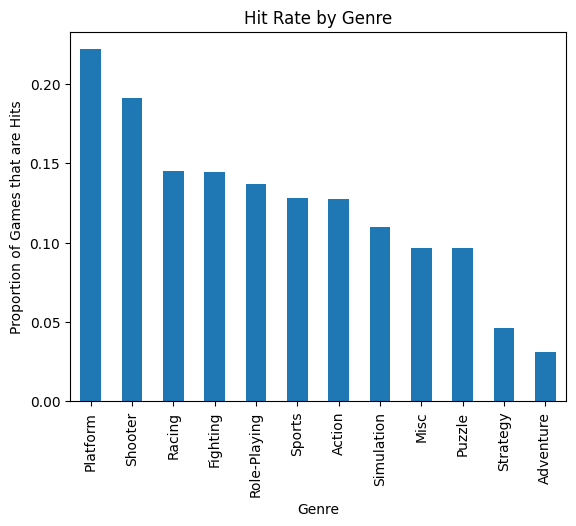

In [ ]:
import matplotlib.pyplot as plt

df.groupby("Genre")["is_hit"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Hit Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Proportion of Games that are Hits")
plt.savefig("chart1.png")
plt.show()